#1. Setup & Load Data

---



In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
df = pd.read_csv('/content/drive/MyDrive/stock_prediction-lstm-tft/02_data/raw/stock_prices.csv')
df.head()

Mounted at /content/drive


,id,symbol,company_name,open_price,high_price,low_price,close_price,volume,price_date
0,2895,ASII.JK,Astra International,4447.92,4447.92,4351.57,4415.80,15008600,2020-01-02
1,2896,ASII.JK,Astra International,4447.92,4463.98,4383.69,4463.98,19068800,2020-01-03
2,2897,ASII.JK,Astra International,4431.86,4431.86,4335.52,4335.52,22261900,2020-01-06
3,2898,ASII.JK,Astra International,4367.63,4383.69,4287.34,4351.57,27963000,2020-01-07
4,2899,ASII.JK,Astra International,4303.40,4383.69,4303.40,4351.57,15150400,2020-01-08


#2. Informasi Dasar Data

---



In [4]:
# Informasi dasar
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7235, 9)

Data Types:
id                int64
symbol           object
company_name     object
open_price      float64
high_price      float64
low_price       float64
close_price     float64
volume            int64
price_date       object
dtype: object

Missing Values:
id              0
symbol          0
company_name    0
open_price      0
high_price      0
low_price       0
close_price     0
volume          0
price_date      0
dtype: int64


In [5]:
# Cek nilai 0 di kolom harga dan volume
print((df[['open_price', 'high_price', 'low_price', 'close_price', 'volume']] == 0).sum())

open_price     0
high_price     0
low_price      0
close_price    0
volume         6
dtype: int64


In [6]:
# Statistik deskriptif
df.describe()

,id,open_price,high_price,low_price,close_price,volume
count,7235.000000,7235.000000,7235.000000,7235.000000,7235.000000,7.235000e+03
mean,3618.000000,5461.684774,5520.714426,5394.179765,5455.926441,5.802059e+07
std,2088.708931,2663.489285,2686.386233,2635.274008,2662.411596,6.429799e+07
min,1.000000,923.720000,1087.830000,923.720000,951.860000,0.000000e+00
25%,1809.500000,3348.015000,3382.015000,3309.570000,3345.930000,1.249805e+07
50%,3618.000000,4512.980000,4559.350000,4447.920000,4512.770000,4.136370e+07
75%,5426.500000,7858.690000,7947.630000,7796.710000,7856.690000,8.206530e+07
max,7235.000000,12498.820000,12572.060000,12254.710000,12498.820000,1.155861e+09


In [7]:
# Cek duplikat berdasarkan symbol dan price_date
print("Duplikat berdasarkan symbol & price_date:")
print(df.duplicated(subset=['symbol', 'price_date']).sum())

Duplikat berdasarkan symbol & price_date:
0


In [8]:
# Distribusi data per saham
print(df['symbol'].value_counts())

symbol
ASII.JK    1447
BBCA.JK    1447
ICBP.JK    1447
TLKM.JK    1447
UNVR.JK    1447
Name: count, dtype: int64


# 3. Data Cleaning


---



In [9]:
# Konversi price_date ke datetime
df['price_date'] = pd.to_datetime(df['price_date'])
print(df.dtypes)

id                       int64
symbol                  object
company_name            object
open_price             float64
high_price             float64
low_price              float64
close_price            float64
volume                   int64
price_date      datetime64[ns]
dtype: object


In [10]:
# Drop baris dengan volume 0
df = df[df['volume'] != 0]

print("Shape setelah cleaning:", df.shape)
print("Volume 0 tersisa:", (df['volume'] == 0).sum())

Shape setelah cleaning: (7229, 9)
Volume 0 tersisa: 0


In [11]:
# Sort data berdasarkan symbol & tanggal
df = df.sort_values(by=['symbol', 'price_date']).reset_index(drop=True)
df.head()

,id,symbol,company_name,open_price,high_price,low_price,close_price,volume,price_date
0,2895,ASII.JK,Astra International,4447.92,4447.92,4351.57,4415.80,15008600,2020-01-02
1,2896,ASII.JK,Astra International,4447.92,4463.98,4383.69,4463.98,19068800,2020-01-03
2,2897,ASII.JK,Astra International,4431.86,4431.86,4335.52,4335.52,22261900,2020-01-06
3,2898,ASII.JK,Astra International,4367.63,4383.69,4287.34,4351.57,27963000,2020-01-07
4,2899,ASII.JK,Astra International,4303.40,4383.69,4303.40,4351.57,15150400,2020-01-08


In [12]:
df.to_csv('/content/drive/MyDrive/stock_prediction-lstm-tft/02_data/clean/lq45_cleaned.csv', index=False)

# 4. Visualisasi Data

1. Bagaimana tren pergerakan harga close masing-masing saham selama 2020–2025?
2. Bagaimana pola volume trading tiap saham dan apakah ada lonjakan signifikan?
3. Seberapa kuat korelasi harga close antar saham LQ45?
4. Bagaimana distribusi harga close masing-masing saham?
5. Bagaimana volatilitas harian (daily return) tiap saham?

---



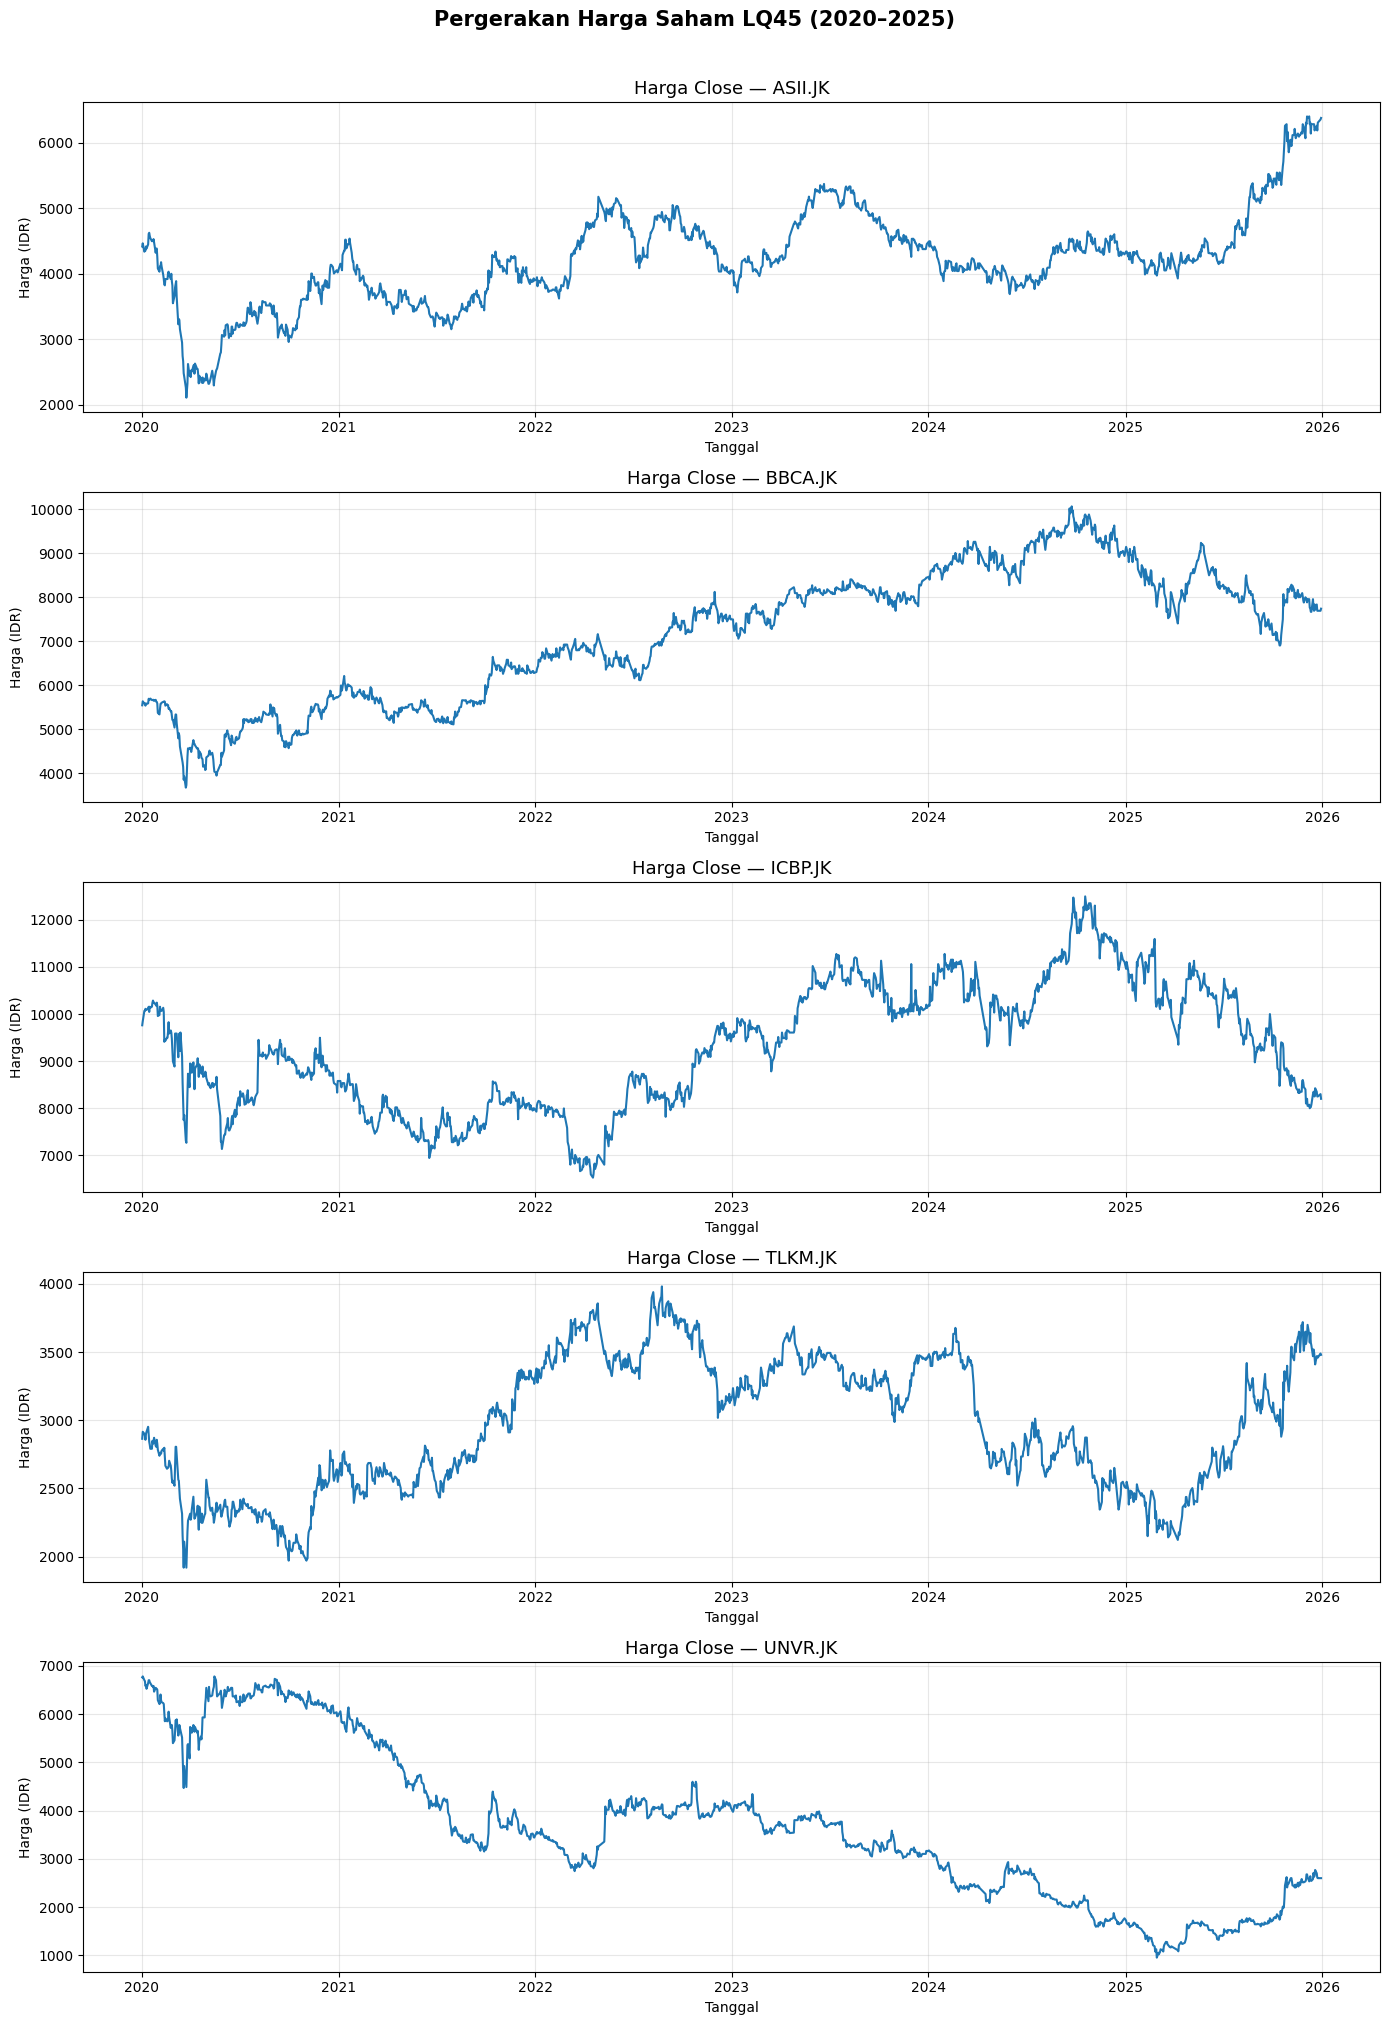

In [13]:
import os
# Plot harga close per saham
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

symbols = df['symbol'].unique()

for i, symbol in enumerate(symbols):
    data = df[df['symbol'] == symbol]
    axes[i].plot(data['price_date'], data['close_price'], linewidth=1.5)
    axes[i].set_title(f'Harga Close — {symbol}', fontsize=13)
    axes[i].set_xlabel('Tanggal')
    axes[i].set_ylabel('Harga (IDR)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Pergerakan Harga Saham LQ45 (2020–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

output_dir = '/content/drive/MyDrive/stock_prediction-lstm-tft/05_results/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'harga_close_per_saham.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#plot volume saham
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for i, symbol in enumerate(symbols):
    data = df[df['symbol'] == symbol].copy()
    data['MA50_vol'] = data['volume'].rolling(50).mean()

    axes[i].bar(data['price_date'], data['volume'], width=1, alpha=0.5, label='Volume')
    axes[i].plot(data['price_date'], data['MA50_vol'], linewidth=1.5, color='red', label='MA50')
    axes[i].set_title(f'Volume Trading — {symbol}', fontsize=13)
    axes[i].set_xlabel('Tanggal')
    axes[i].set_ylabel('Volume')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Volume Trading Saham LQ45 (2020–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'volume_per_saham.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Plot Korelasi Harga Close Antar Saham LQ45
pivot_close = df.pivot(index='price_date', columns='symbol', values='close_price')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_close.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Harga Close Antar Saham LQ45')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'korelasi_antar_saham.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Distribusi harga close per saham
plt.figure(figsize=(10, 6))
df.boxplot(column='close_price', by='symbol', figsize=(10, 6))
plt.suptitle('')
plt.title('Distribusi Harga Close per Saham')
plt.xlabel('Saham')
plt.ylabel('Harga (IDR)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'distribusi_close.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Daily return per saham (harian)
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for i, symbol in enumerate(symbols):
    data = df[df['symbol'] == symbol].copy()
    data['daily_return'] = data['close_price'].pct_change() * 100

    axes[i].plot(data['price_date'], data['daily_return'], linewidth=0.8, alpha=0.7)
    axes[i].axhline(y=0, color='red', linewidth=1, linestyle='--')
    axes[i].set_title(f'Daily Return — {symbol}', fontsize=13)
    axes[i].set_xlabel('Tanggal')
    axes[i].set_ylabel('Return (%)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Daily Return Saham LQ45 (2020–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'daily_return.png'), dpi=150, bbox_inches='tight')
plt.show()

# 5. Kesimpulan EDA

Berdasarkan eksplorasi data yang telah dilakukan, diperoleh beberapa temuan:

1. Dataset terdiri dari 7229 baris data setelah proses cleaning, mencakup 5 saham LQ45 dalam periode 2020–2025.
2. Tidak ditemukan missing values maupun duplikat pada dataset.
3. Terdapat 6 baris dengan volume 0 yang dihapus karena tidak mencerminkan aktivitas perdagangan normal, mayoritas terjadi pada periode COVID-19 Maret 2020.
4. Tren harga masing-masing saham menunjukkan:  
   - **BBCA** sempat terkoreksi dari Rp5.000 ke Rp4.000 di awal 2020, namun setelah
     itu menunjukkan tren positif yang konsisten hingga mencapai Rp10.000 di akhir
     2024, sebelum mengalami tekanan penurunan pada periode 2024–2025.
   - **ICBP** mencatat tren negatif di awal periode dari Rp10.000 turun ke Rp8.000
     pada 2020–2022, kemudian berbalik naik hingga Rp12.000 di akhir 2024, dan
     kembali mengalami penurunan ke Rp8.000 pada 2024–2025.
   - **TLKM** mengalami penurunan dari Rp3.000 ke Rp2.000 di awal 2020, kemudian
     bounce back dengan tren sangat positif hingga mencapai puncaknya di Rp4.000
     pada pertengahan 2022. Setelah itu tren berbalik negatif kembali ke Rp2.000
     sebelum menguat lagi ke Rp3.500 di akhir 2025.
   - **UNVR** mencatat tren negatif yang konsisten dan paling ekstrem sepanjang
     2020–2025, dengan harga turun drastis dari sekitar Rp7.000 menjadi Rp1.000,
     mencerminkan tekanan fundamental jangka panjang pada perusahaan.  
5. Korelasi antar saham menunjukkan pola yang bervariasi. Dari sisi korelasi positif, BBCA dan ICBP memiliki korelasi tertinggi sebesar 0.75 yang tergolong kuat, diikuti ASII dengan TLKM sebesar 0.64 dan ASII dengan BBCA sebesar 0.57 yang keduanya tergolong cukup kuat. Sementara dari sisi korelasi negatif, BBCA dan UNVR mencatat korelasi paling ekstrem sebesar -0.82, mengindikasikan bahwa kenaikan harga BBCA cenderung diikuti penurunan harga UNVR. ASII dan UNVR menunjukkan korelasi negatif sedang sebesar -0.49, sedangkan TLKM dan UNVR memiliki korelasi negatif lemah sebesar -0.26. Pola ini mengindikasikan bahwa UNVR bergerak berlawanan arah dengan mayoritas saham lainnya, yang sejalan dengan tren penurunan harga UNVR yang konsisten sepanjang periode pengamatan.